In [1]:
from zipfile import ZipFile
file_name='/content/MIt-BIH Datasets.zip'
with ZipFile(file_name,'r') as zipp:
  zipp.extractall()

In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score
from sklearn.metrics import confusion_matrix
from keras.utils.np_utils import to_categorical
from sklearn.utils import class_weight
import warnings

from keras.preprocessing.sequence import TimeseriesGenerator

from keras.models import Sequential
from keras.layers import Reshape
from keras.models import Model

from keras.layers import Dense, Activation, Flatten, Convolution1D, Dropout,MaxPooling1D , Input
from tensorflow.keras.optimizers import Adam 
from keras.callbacks import LearningRateScheduler

import itertools
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, label_ranking_average_precision_score, label_ranking_loss, coverage_error 

from tensorflow.keras.layers import BatchNormalization
import pandas
import numpy as np
import tensorflow as tf
from keras.models import Sequential
from keras.wrappers.scikit_learn import KerasClassifier
from keras.layers import Dropout, Flatten, Dense 
from keras.utils import np_utils
from keras import optimizers
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import BaggingClassifier
from numpy import mean
from numpy import std
from tensorflow.keras.optimizers import Adam , Adadelta

import tensorflow as tf
from tensorflow.keras.layers import Flatten, Dense, Conv1D, MaxPool1D, Dropout

warnings.filterwarnings('ignore')

In [3]:
import pandas as pd
train = pd.read_csv("/content/MIt-BIH Datasets/train.csv" , header = None)
validate = pd.read_csv("/content/MIt-BIH Datasets/validate.csv", header = None)
test = pd.read_csv("/content/MIt-BIH Datasets/test.csv" , header = None)


In [4]:
combine = [train , validate]

In [5]:
train = pd.concat(combine , axis = 0 )

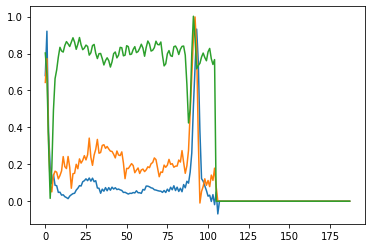

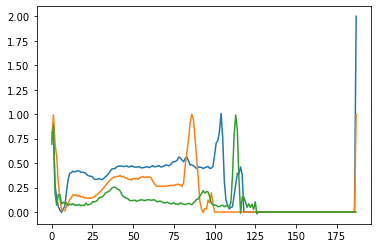

In [6]:
for i in range(3): plt.plot(train.iloc[i])
plt.show()
for i in range(3): plt.plot(test.iloc[i])
plt.show()

In [7]:
train.rename(columns={187:"Class"}, inplace=True)
test.rename(columns={187:"Class"}, inplace=True)


In [8]:
train['Class'].unique()

array([ 0., 15.,  8., 17.,  2.,  1.,  4., 12.,  5., 14., 10.,  6., 18.])

In [9]:
mapping = {    
               0 : 'Normal Beat',
               1 : 'Left bundle branch block beat',
               2 : 'Right bundle branch block beat',
               4 : 'Atrial premature beat',
               5 : 'Aberrated atrial premature beat',
               6 : 'Nodal (junctional) premature beat',
             
               8 : 'Premature ventricular contraction',
               10 : 'Fusion of ventricular and normal beat',
             
               12 : 'Nodal (junctional) escape beat',
               14 : 'Ventricular escape beat',
               15 : 'Paced beat',
             
               17 : 'Unclassifiable beat',
                18: 'Fusion of paced and normal beat'

               }

In [10]:
train['label'] = train.iloc[:, -1].map(mapping)
test['label'] = test.iloc[:, -1].map(mapping)


In [11]:
# Applying Smote
df_15=train[train['Class']==15]
df_2=train[train['Class']==2]
df_1=train[train['Class']==1]
df_8=train[train['Class']==8]
df_4=train[train['Class']==4]

df_10=train[train['Class']==10]
df_12=train[train['Class']==12]
df_6=train[train['Class']==6]
df_14=train[train['Class']==14]
df_5=train[train['Class']==5]
df_17=train[train['Class']==17]
df_18= train[train['Class']==18]



df_0=(train[train['Class']==0]).sample(n=20000,random_state=42)


train=pd.concat([df_0,df_15,df_2,df_1,df_8,df_4,df_10,df_12,df_6,df_14,df_5,df_17,df_18])

In [12]:
X_train=train.iloc[:,:186].values
X_test=test.iloc[:,:186].values


In [13]:
from imblearn.over_sampling import SMOTE
oversample = SMOTE(k_neighbors=1)
X_train, y_train = oversample.fit_resample(X_train, train["Class"])


In [14]:
from collections import Counter

counter = Counter(y_train)
print(counter)

Counter({0.0: 20000, 15.0: 20000, 2.0: 20000, 1.0: 20000, 8.0: 20000, 4.0: 20000, 10.0: 20000, 12.0: 20000, 6.0: 20000, 14.0: 20000, 5.0: 20000, 17.0: 20000, 18.0: 20000})


In [15]:
X_train = X_train.reshape(len(X_train), X_train.shape[1],1)
X_test = X_test.reshape(len(X_test), X_test.shape[1],1)


In [16]:
target_test=test["Class"]
y_test = target_test

In [17]:
y_train = np.array(y_train)
y_test = np.array(y_test)

In [18]:
X_train.shape

(260000, 186, 1)

In [19]:
pip install attention

     |████████████████████████████████| 462 kB 38.5 MB/s 


In [20]:

from tensorflow.keras.optimizers import SGD
NUM_EPOCHS = 25
INIT_LR = 1e-2
BS = 500
opt = SGD(lr=INIT_LR, momentum=0.9, decay=INIT_LR / NUM_EPOCHS)


In [21]:
!pip install scikeras
from scikeras.wrappers import KerasClassifier

In [22]:
# attention model
from tensorflow.keras.layers import Conv1D, Input, LSTM, Activation, Dense, Average
from tensorflow.keras import regularizers
from keras.layers import BatchNormalization

from attention import Attention


inputs_1 = Input(shape = (186,1))

def Attention_Network(neurons=200):
  

  x = LSTM(64, return_sequences = True)(inputs_1)


  x = Attention(units=32)(x)

  x = Conv1D(128 ,5)(inputs_1)
  x = Activation('relu')(x)

  x = Conv1D(64 ,5 )(x)
  x = Activation('relu')(x)


  x = Conv1D(32 ,5 )(x)
  x = Activation('relu')(x)

  x=Flatten()(x)


  x = Dense(256)(x)
  x = BatchNormalization()(x)
  x = Activation('relu')(x)
  x = Dense(127)(x)
  x= BatchNormalization()(x)
  x = Activation('relu')(x)
  outputs = Dense(13, activation = 'softmax')(x)
  model = tf.keras.models.Model(inputs = inputs_1, outputs = outputs)
  
  
  
  
  model.compile(optimizer='adam' , loss='sparse_categorical_crossentropy', metrics=['accuracy'])
  return model


attention_clf = KerasClassifier(build_fn=Attention_Network, epochs=10, batch_size=500, verbose=1)
attention_clf._estimator_type = "classifier"


In [23]:
n_obs, feature, depth = X_train.shape
batch_size = 500

In [24]:

# model Residual

from keras.layers import Input, Dense, Conv1D, MaxPooling1D, Softmax, Add, Flatten, Activation# , Dropout

def Residual_Network(neurons = 200):
  inp = Input(shape=(feature, depth))
  C = Conv1D(filters=32, kernel_size=5, strides=1)(inp)
  C11 = Conv1D(filters=32, kernel_size=5, strides=1, padding='same')(C)
  A11 = Activation("relu")(C11)

  C12 = Conv1D(filters=32, kernel_size=5, strides=1, padding='same')(A11)
  S11 = Add()([C12, C])
  A12 = Activation("relu")(S11)
  M11 = MaxPooling1D(pool_size=5, strides=2)(A12)


  C21 = Conv1D(filters=32, kernel_size=5, strides=1, padding='same')(M11)
  A21 = Activation("relu")(C21)
  C22 = Conv1D(filters=32, kernel_size=5, strides=1, padding='same')(A21)
  S21 = Add()([C22, M11])
  A22 = Activation("relu")(S11)
  M21 = MaxPooling1D(pool_size=5, strides=2)(A22)


  C31 = Conv1D(filters=32, kernel_size=5, strides=1, padding='same')(M21)
  A31 = Activation("relu")(C31)
  C32 = Conv1D(filters=32, kernel_size=5, strides=1, padding='same')(A31)
  S31 = Add()([C32, M21])
  A32 = Activation("relu")(S31)
  M31 = MaxPooling1D(pool_size=5, strides=2)(A32)


  C41 = Conv1D(filters=32, kernel_size=5, strides=1, padding='same')(M31)
  A41 = Activation("relu")(C41)
  C42 = Conv1D(filters=32, kernel_size=5, strides=1, padding='same')(A41)
  S41 = Add()([C42, M31])
  A42 = Activation("relu")(S41)
  M41 = MaxPooling1D(pool_size=5, strides=2)(A42)


  C51 = Conv1D(filters=32, kernel_size=5, strides=1, padding='same')(M41)
  A51 = Activation("relu")(C51)
  C52 = Conv1D(filters=32, kernel_size=5, strides=1, padding='same')(A51)
  S51 = Add()([C52, M41])
  A52 = Activation("relu")(S51)
  M51 = MaxPooling1D(pool_size=5, strides=2)(A52)

  F1 = Flatten()(M51)

  D1 = Dense(32)(F1)
  A6 = Activation("relu")(D1)
  D2 = Dense(32)(A6)
  D3 = Dense(13)(D2)
  A7 = Softmax()(D3)

  model = Model(inputs=inp, outputs=A7)
  model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
  return model


Residual_clf = KerasClassifier(build_fn=Residual_Network, epochs=10, batch_size=500, verbose=1)
Residual_clf._estimator_type = "classifier"



In [25]:
from sklearn.model_selection import cross_val_score, StratifiedKFold
from collections import defaultdict

In [26]:
models_dict = {
      'Attantion':attention_clf,
      'Residual': Residual_clf
               
               }

In [27]:
def evaluate_model(model, X, y):
    cv = StratifiedKFold(n_splits=5)
    scores = cross_val_score(model, X, y, scoring='accuracy', cv=cv, verbose=1,  error_score='raise')
    return scores

In [28]:
model_scores = defaultdict()

In [29]:
for name, model in models_dict.items():
    print('Evaluating {}'.format(name))
    scores = evaluate_model(model, X_train, y_train)
    model_scores[name] = scores

Evaluating Attantion


[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.


Epoch 1/10
416/416 [==============================] - 26s 24ms/step - loss: 0.1679 - accuracy: 0.9534
Epoch 2/10
416/416 [==============================] - 9s 21ms/step - loss: 0.0288 - accuracy: 0.9920
Epoch 3/10
416/416 [==============================] - 9s 22ms/step - loss: 0.0160 - accuracy: 0.9952
Epoch 4/10
416/416 [==============================] - 9s 22ms/step - loss: 0.0100 - accuracy: 0.9970
Epoch 5/10
416/416 [==============================] - 9s 22ms/step - loss: 0.0081 - accuracy: 0.9977
Epoch 6/10
416/416 [==============================] - 9s 22ms/step - loss: 0.0061 - accuracy: 0.9982
Epoch 7/10
416/416 [==============================] - 9s 22ms/step - loss: 0.0077 - accuracy: 0.9977
Epoch 8/10
416/416 [==============================] - 9s 22ms/step - loss: 0.0052 - accuracy: 0.9985
Epoch 9/10
416/416 [==============================] - 9s 22ms/step - loss: 0.0039 - accuracy: 0.9988
Epoch 10/10
104/104 [==============================] - 1s 7ms/step
Epoch 1/10
416/416 [===

[Parallel(n_jobs=1)]: Done   5 out of   5 | elapsed: 10.7min finished
[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.


Evaluating Residual
Epoch 1/10
416/416 [==============================] - 8s 13ms/step - loss: 0.6230 - accuracy: 0.7964
Epoch 2/10
416/416 [==============================] - 6s 14ms/step - loss: 0.1726 - accuracy: 0.9474
Epoch 3/10
416/416 [==============================] - 6s 13ms/step - loss: 0.1084 - accuracy: 0.9662
Epoch 4/10
416/416 [==============================] - 6s 14ms/step - loss: 0.0803 - accuracy: 0.9747
Epoch 5/10
416/416 [==============================] - 6s 14ms/step - loss: 0.0650 - accuracy: 0.9792
Epoch 6/10
416/416 [==============================] - 6s 14ms/step - loss: 0.0534 - accuracy: 0.9831
Epoch 7/10
416/416 [==============================] - 6s 14ms/step - loss: 0.0469 - accuracy: 0.9847
Epoch 8/10
416/416 [==============================] - 6s 14ms/step - loss: 0.0436 - accuracy: 0.9856
Epoch 9/10
416/416 [==============================] - 6s 14ms/step - loss: 0.0376 - accuracy: 0.9879
Epoch 10/10
104/104 [==============================] - 1s 5ms/step
Epoc

[Parallel(n_jobs=1)]: Done   5 out of   5 | elapsed:  6.2min finished


In [30]:
pip install datapane


     |████████████████████████████████| 2.6 MB 35.1 MB/s 
     |████████████████████████████████| 46 kB 4.8 MB/s 
     |████████████████████████████████| 54 kB 3.1 MB/s 
     |████████████████████████████████| 193 kB 72.6 MB/s 
     |████████████████████████████████| 97 kB 8.7 MB/s 
     |████████████████████████████████| 11.1 MB 63.2 MB/s 
     |████████████████████████████████| 45 kB 4.7 MB/s 
     |████████████████████████████████| 596 kB 64.2 MB/s 
     |████████████████████████████████| 46 kB 4.2 MB/s 
  Created wheel for face: filename=face-20.1.1-py3-none-any.whl size=51091 sha256=f0ad2b3c3964e96ef2bee8b14b7d0dd9d3a6f3872c72cdea9346478ec13384f7
  Stored in directory: /root/.cache/pip/wheels/67/03/c2/76d2e1e694852ce409ac2938b9f461bc0fdf3789901e7bb1f0
  Created wheel for micawber: filename=micawber-0.5.4-py3-none-any.whl size=22373 sha256=47f6bc4a02b8da04aaea59df5c4d5154ff2425c2d5df8911173a7d6d4a4e0117
  Stored in directory: /root/.cache/pip/wheels/c1/b6/81/f8237c6061ac239fe1079fa

In [31]:
import plotly.graph_objects as go
import datapane as dp

In [32]:
def plot_results(model_scores, name):
    
    model_names = list(model_scores.keys())
    results = [model_scores[model] for model in model_names]
    fig = go.Figure()
    for model, result in zip(model_names, results):
        fig.add_trace(go.Box(
            y=result,
            name=model,
            boxpoints='all',
            jitter=0.5,
            whiskerwidth=0.2,
            marker_size=2,
            line_width=1)
        )
    
    fig.update_layout(
    title='Performance of Different Models Using 5-Fold Cross-Validation',
    paper_bgcolor='rgb(243, 243, 243)',
    plot_bgcolor='rgb(243, 243, 243)',
    xaxis_title='Model',
    yaxis_title='Accuracy',
    showlegend=False)
    fig.show()
    
    report = dp.Report(dp.Plot(fig) ) #Create a report
    #report.publish(name=name, open=True, visibility='PUBLIC') 

plot_results(model_scores, name='base_models_cv')

Bokeh version 2.3.3 is not supported, these plots may not display correctly, please install version ~=2.2.0
Folium version 0.8.3 is not supported, these plots may not display correctly, please install version >=0.12.0


In [33]:
#cv = 5
n_estimator =5
bagging_classifier_attention = BaggingClassifier(base_estimator=attention_clf, n_estimators=3 ,
                                    verbose=2)

#cv = 5
bagging_classifier_residual = BaggingClassifier(base_estimator=Residual_clf,n_estimators=3 ,
                                    verbose=2)


In [34]:
X_train = X_train.reshape(260000,186)

In [35]:
bagging_scores_attention = evaluate_model(bagging_classifier_attention, X_train, y_train)

[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.


Building estimator 1 of 3 for this parallel run (total 3)...
Epoch 1/10
416/416 [==============================] - 11s 22ms/step - loss: 0.1983 - accuracy: 0.9435
Epoch 2/10
416/416 [==============================] - 9s 22ms/step - loss: 0.0437 - accuracy: 0.9863
Epoch 3/10
416/416 [==============================] - 9s 22ms/step - loss: 0.0221 - accuracy: 0.9918
Epoch 4/10
416/416 [==============================] - 9s 22ms/step - loss: 0.0163 - accuracy: 0.9937
Epoch 5/10
416/416 [==============================] - 10s 23ms/step - loss: 0.0114 - accuracy: 0.9951
Epoch 6/10
416/416 [==============================] - 10s 23ms/step - loss: 0.0124 - accuracy: 0.9948
Epoch 7/10
416/416 [==============================] - 9s 23ms/step - loss: 0.0081 - accuracy: 0.9958
Epoch 8/10
416/416 [==============================] - 9s 23ms/step - loss: 0.0109 - accuracy: 0.9952
Epoch 9/10
416/416 [==============================] - 9s 23ms/step - loss: 0.0048 - accuracy: 0.9971
Epoch 10/10
416/416 [======

[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:  7.6min remaining:    0.0s
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:  7.6min finished
[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.


104/104 [==============================] - 1s 7ms/step


[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    3.4s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    3.4s finished
[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.


...

[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    2.8s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    2.8s finished
[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.


Epoch 1/10
416/416 [==============================] - 11s 22ms/step - loss: 0.2157 - accuracy: 0.9393
Epoch 2/10
416/416 [==============================] - 9s 22ms/step - loss: 0.0502 - accuracy: 0.9837
Epoch 3/10
416/416 [==============================] - 9s 22ms/step - loss: 0.0285 - accuracy: 0.9896
Epoch 4/10
416/416 [==============================] - 9s 22ms/step - loss: 0.0180 - accuracy: 0.9926
Epoch 5/10
416/416 [==============================] - 9s 22ms/step - loss: 0.0150 - accuracy: 0.9937
Epoch 6/10
416/416 [==============================] - 9s 22ms/step - loss: 0.0103 - accuracy: 0.9951
Epoch 7/10
416/416 [==============================] - 9s 23ms/step - loss: 0.0116 - accuracy: 0.9946
Epoch 8/10
416/416 [==============================] - 9s 23ms/step - loss: 0.0094 - accuracy: 0.9950
Epoch 9/10
416/416 [==============================] - 9s 23ms/step - loss: 0.0080 - accuracy: 0.9957
Epoch 10/10
416/416 [==============================] - 9s 23ms/step - loss: 0.0080 - accur

[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:  8.1min remaining:    0.0s
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:  8.1min finished
[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.


104/104 [==============================] - 1s 7ms/step


[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    4.5s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    4.5s finished
[Parallel(n_jobs=1)]: Done   5 out of   5 | elapsed: 41.2min finished


In [36]:
bagging_score_residual = evaluate_model(bagging_classifier_residual, X_train, y_train)

[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.


Building estimator 1 of 3 for this parallel run (total 3)...
Epoch 1/10
416/416 [==============================] - 7s 14ms/step - loss: 0.6875 - accuracy: 0.7732
Epoch 2/10
416/416 [==============================] - 6s 14ms/step - loss: 0.1919 - accuracy: 0.9397
Epoch 3/10
416/416 [==============================] - 6s 14ms/step - loss: 0.1225 - accuracy: 0.9606
Epoch 4/10
416/416 [==============================] - 6s 14ms/step - loss: 0.0909 - accuracy: 0.9706
Epoch 5/10
416/416 [==============================] - 6s 13ms/step - loss: 0.0738 - accuracy: 0.9755
Epoch 6/10
416/416 [==============================] - 6s 14ms/step - loss: 0.0655 - accuracy: 0.9779
Epoch 7/10
416/416 [==============================] - 6s 14ms/step - loss: 0.0538 - accuracy: 0.9818
Epoch 8/10
416/416 [==============================] - 6s 14ms/step - loss: 0.0505 - accuracy: 0.9824
Epoch 9/10
416/416 [==============================] - 6s 14ms/step - loss: 0.0436 - accuracy: 0.9847
Epoch 10/10
416/416 [=========

[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:  5.5min remaining:    0.0s
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:  5.5min finished
[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.


104/104 [==============================] - 1s 5ms/step


[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    2.7s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    2.7s finished
[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.


...

[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    2.4s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    2.4s finished
[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.


Epoch 1/10
416/416 [==============================] - 7s 14ms/step - loss: 0.6668 - accuracy: 0.7815
Epoch 2/10
416/416 [==============================] - 6s 14ms/step - loss: 0.2125 - accuracy: 0.9335
Epoch 3/10
416/416 [==============================] - 6s 14ms/step - loss: 0.1366 - accuracy: 0.9566
Epoch 4/10
416/416 [==============================] - 6s 14ms/step - loss: 0.1024 - accuracy: 0.9672
Epoch 5/10
416/416 [==============================] - 6s 14ms/step - loss: 0.0847 - accuracy: 0.9729
Epoch 6/10
416/416 [==============================] - 6s 14ms/step - loss: 0.0715 - accuracy: 0.9766
Epoch 7/10
416/416 [==============================] - 6s 14ms/step - loss: 0.0648 - accuracy: 0.9787
Epoch 8/10
416/416 [==============================] - 6s 14ms/step - loss: 0.0550 - accuracy: 0.9816
Epoch 9/10
416/416 [==============================] - 6s 14ms/step - loss: 0.0486 - accuracy: 0.9836
Epoch 10/10
416/416 [==============================] - 6s 14ms/step - loss: 0.0462 - accura

[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:  5.5min remaining:    0.0s
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:  5.5min finished
[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.


104/104 [==============================] - 1s 5ms/step


[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    2.6s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    2.6s finished
[Parallel(n_jobs=1)]: Done   5 out of   5 | elapsed: 26.9min finished


In [37]:
model_scores['Bagging_Attention'] = bagging_scores_attention
model_scores['Bagging_Residual'] = bagging_score_residual

In [38]:
plot_results(model_scores, name='Bagging_model_cv')

In [39]:
# evaluate bagging ensemble for regression
from numpy import mean
from numpy import std

for model in model_scores:
     print(model, '->', model_scores[model]  , 'MAE: %.3f (%.3f)' % (mean(model_scores[model]), std(model_scores[model])))


Attantion -> [0.98707692 0.99598077 0.99726923 0.99748077 0.99701923] MAE: 0.995 (0.004)
Residual -> [0.98278846 0.98934615 0.98996154 0.98778846 0.98857692] MAE: 0.988 (0.003)
Bagging_Attention -> [0.99378846 0.99578846 0.99761538 0.99734615 0.99634615] MAE: 0.996 (0.001)
Bagging_Residual -> [0.987      0.98953846 0.99069231 0.99136538 0.98940385] MAE: 0.990 (0.001)


In [40]:
bagg_model_attention = bagging_classifier_attention.fit(X_train,y_train)

[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.


Building estimator 1 of 3 for this parallel run (total 3)...
Epoch 1/10
520/520 [==============================] - 13s 22ms/step - loss: 0.1900 - accuracy: 0.9462
Epoch 2/10
520/520 [==============================] - 12s 22ms/step - loss: 0.0413 - accuracy: 0.9862
Epoch 3/10
520/520 [==============================] - 12s 22ms/step - loss: 0.0211 - accuracy: 0.9920
Epoch 4/10
520/520 [==============================] - 12s 22ms/step - loss: 0.0146 - accuracy: 0.9940
Epoch 5/10
520/520 [==============================] - 12s 23ms/step - loss: 0.0117 - accuracy: 0.9947
Epoch 6/10
520/520 [==============================] - 12s 23ms/step - loss: 0.0129 - accuracy: 0.9946
Epoch 7/10
520/520 [==============================] - 12s 23ms/step - loss: 0.0097 - accuracy: 0.9955
Epoch 8/10
520/520 [==============================] - 12s 23ms/step - loss: 0.0063 - accuracy: 0.9964
Epoch 9/10
520/520 [==============================] - 12s 23ms/step - loss: 0.0069 - accuracy: 0.9962
Epoch 10/10
520/520 [

[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:  9.0min remaining:    0.0s
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:  9.0min finished


In [41]:
bagg_model_residual = bagging_classifier_residual.fit(X_train,y_train)

[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.


Building estimator 1 of 3 for this parallel run (total 3)...
Epoch 1/10
520/520 [==============================] - 8s 14ms/step - loss: 0.6191 - accuracy: 0.7960
Epoch 2/10
520/520 [==============================] - 7s 14ms/step - loss: 0.1719 - accuracy: 0.9464
Epoch 3/10
520/520 [==============================] - 7s 14ms/step - loss: 0.1103 - accuracy: 0.9649
Epoch 4/10
520/520 [==============================] - 7s 14ms/step - loss: 0.0861 - accuracy: 0.9718
Epoch 5/10
520/520 [==============================] - 7s 14ms/step - loss: 0.0690 - accuracy: 0.9770
Epoch 6/10
520/520 [==============================] - 7s 14ms/step - loss: 0.0589 - accuracy: 0.9798
Epoch 7/10
520/520 [==============================] - 7s 14ms/step - loss: 0.0510 - accuracy: 0.9827
Epoch 8/10
520/520 [==============================] - 7s 14ms/step - loss: 0.0462 - accuracy: 0.9836
Epoch 9/10
520/520 [==============================] - 7s 14ms/step - loss: 0.0422 - accuracy: 0.9852
Epoch 10/10
520/520 [=========

[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:  6.4min remaining:    0.0s
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:  6.4min finished


In [43]:
X_test.shape

(29865, 186, 1)

In [44]:
X_test = X_test.reshape(29865,186)

In [45]:
y_pred_attention = bagg_model_attention.predict(X_test)

 1/60 [..............................] - ETA: 6s

[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.


60/60 [==============================] - 1s 7ms/step


[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    2.2s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    2.2s finished


In [46]:
y_pred_residual = bagg_model_residual.predict(X_test)

[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.


60/60 [==============================] - 0s 5ms/step


[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    2.2s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    2.2s finished


In [47]:
print("Bagging Accuracy With Lstm is : " , accuracy_score(y_test, y_pred_attention) )
print("Bagging Accuracy With No Residual is : " , accuracy_score(y_test, y_pred_residual) )

Bagging Accuracy With Lstm is :  0.9716390423572744
Bagging Accuracy With No Residual is :  0.9673530889000502


In [48]:
def plot_confusion_matrix(cm, classes,
                          normalize=False,
                          title='Confusion matrix',
                          cmap=plt.cm.Blues):
    """
    This function prints and plots the confusion matrix.
    Normalization can be applied by setting `normalize=True`.
    """
    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        print("Normalized confusion matrix")
    else:
        print('Confusion matrix, without normalization')

    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)

    fmt = '.2f' if normalize else 'd'
    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j], fmt),
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")

    plt.tight_layout()
    plt.ylabel('True label')
    plt.xlabel('Predicted label')



Confusion matrix, without normalization


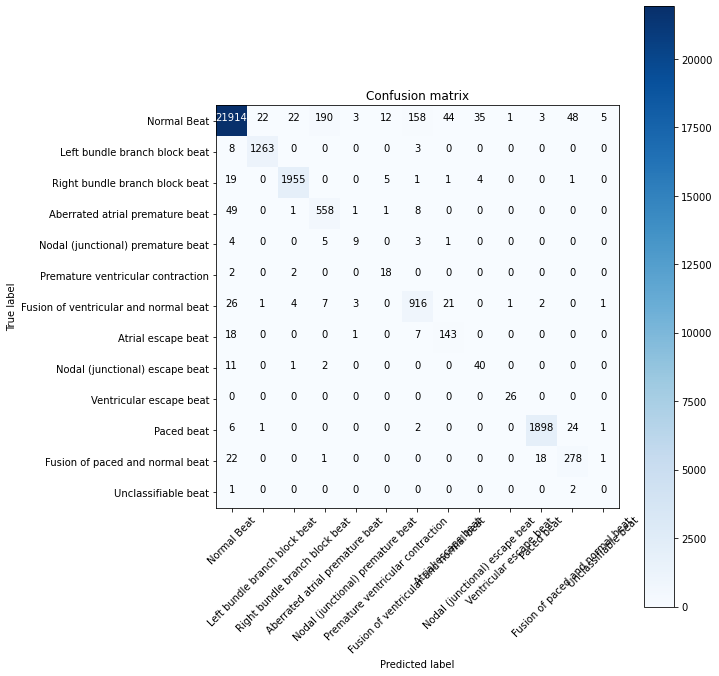

In [49]:
# Compute confusion matrix
cnf_matrix_attention = confusion_matrix(y_test, y_pred_attention)

# Plot non-normalized confusion matrix
plt.figure(figsize=(10, 10))
plot_confusion_matrix(cnf_matrix_attention, classes=['Normal Beat',
                'Left bundle branch block beat',
                'Right bundle branch block beat',
              
                'Aberrated atrial premature beat',
                'Nodal (junctional) premature beat',
          
                'Premature ventricular contraction',
                'Fusion of ventricular and normal beat',
                'Atrial escape beat',
                'Nodal (junctional) escape beat',
                'Ventricular escape beat',
                'Paced beat',
                'Fusion of paced and normal beat',
                'Unclassifiable beat'],
                      title='Confusion matrix')
plt.show()

Confusion matrix, without normalization


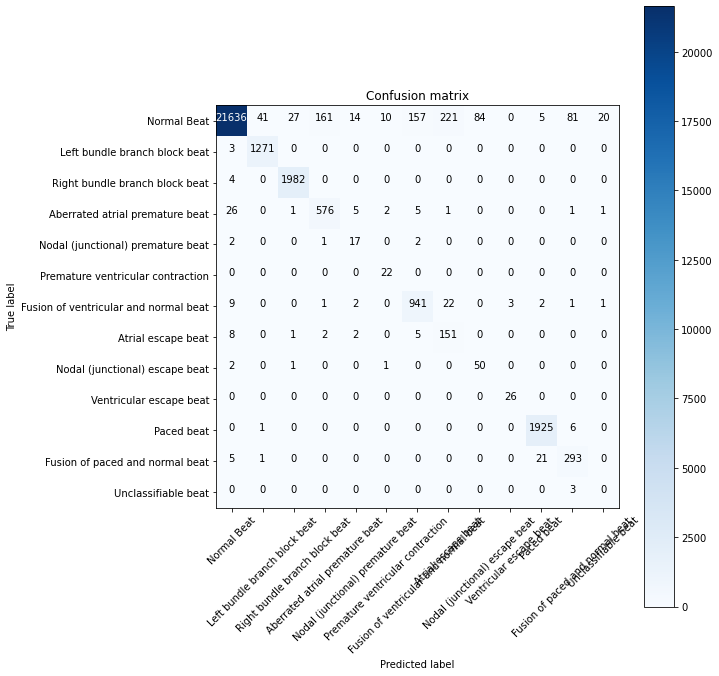

In [50]:
# Compute confusion matrix
cnf_matrix_residual = confusion_matrix(y_test, y_pred_residual)

# Plot non-normalized confusion matrix
plt.figure(figsize=(10, 10))
plot_confusion_matrix(cnf_matrix_residual, classes=['Normal Beat',
                'Left bundle branch block beat',
                'Right bundle branch block beat',
              
                'Aberrated atrial premature beat',
                'Nodal (junctional) premature beat',
         
                'Premature ventricular contraction',
                'Fusion of ventricular and normal beat',
                'Atrial escape beat',
                'Nodal (junctional) escape beat',
                'Ventricular escape beat',
                'Paced beat',
                'Fusion of paced and normal beat',
                'Unclassifiable beat'],
                      title='Confusion matrix')
plt.show()

In [51]:
from sklearn import metrics
fpr_attention, tpr_attention, thresholds_attention = metrics.roc_curve(y_test, y_pred_attention, pos_label=2)

In [52]:
from sklearn import metrics
fpr_residual, tpr_residual, thresholds_residual = metrics.roc_curve(y_test, y_pred_residual, pos_label=2)

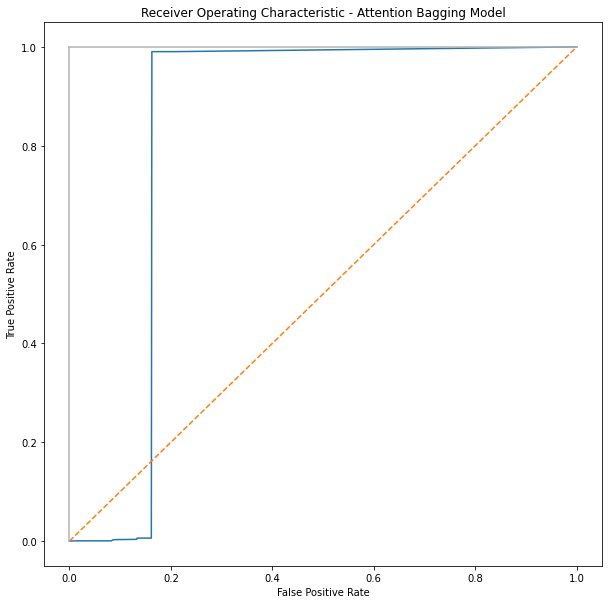

In [53]:
plt.subplots(1, figsize=(10,10))
plt.title('Receiver Operating Characteristic - Attention Bagging Model')
plt.plot(fpr_attention, tpr_attention)
plt.plot([0, 1], ls="--")
plt.plot([0, 0], [1, 0] , c=".7"), plt.plot([1, 1] , c=".7")
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
plt.show()

In [54]:
from sklearn import metrics
auc_attention = metrics.auc(fpr_attention, tpr_attention)
print("Attention Auc is : ")
print(auc_attention )

Attention Auc is : 
0.834151861191835


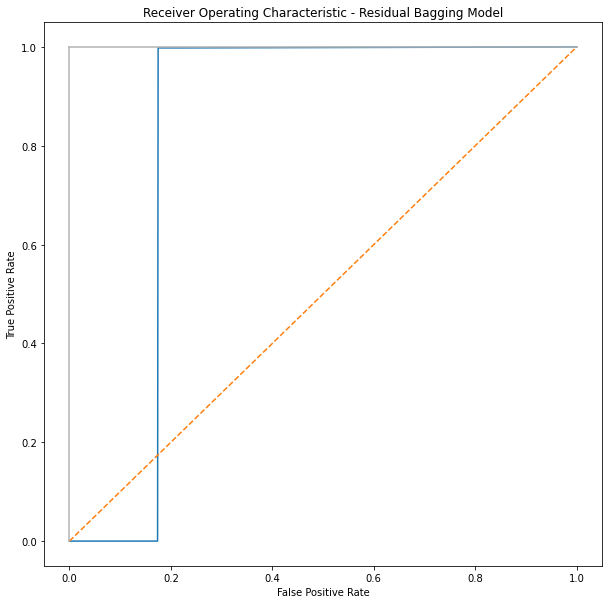

In [55]:
plt.subplots(1, figsize=(10,10))
plt.title('Receiver Operating Characteristic - Residual Bagging Model')
plt.plot(fpr_residual, tpr_residual)
plt.plot([0, 1], ls="--")
plt.plot([0, 0], [1, 0] , c=".7"), plt.plot([1, 1] , c=".7")
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
plt.show()

In [56]:
from sklearn import metrics
auc_residual = metrics.auc(fpr_residual, tpr_residual)
print("Residual Auc is : ")
print(auc_residual )

Residual Auc is : 
0.8248315705544824
